In [1]:
import os
import glob
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = os.getcwd()      # Root DIR 설정
AUDIO_DIR = os.path.join(BASE_DIR, 'audio')     # 오디오 파일이 저장된 루트 폴더
SPEC_DIR = os.path.join(BASE_DIR, 'spectrogram_data')       # 오디오를 이미지로 변환하여 저장할 루트 폴더
SPLIT_DIR = os.path.join(BASE_DIR, 'spectrogram_split')     # CNN 학습용으로 train/val/test 구조로 나누어 저아 루트 폴더
BEST_MODEL_PATH = os.path.join(BASE_DIR, 'best_instrument_cnn_model.keras')        # 최종 학습 모델 저장 경로
TEMP_PREDICT_IMAGE_PATH = os.path.join(BASE_DIR, 'temp_predict_spectrogram.png')   # 신규 예측시 임시로 스펙트로그램 이미지를 저장할 경로

CLASSES = ['Bee', 'Normal', 'Hornet']

# CNN 입역 이미지 높이
IMG_HEIGHT = 224

# CNN 입력 이미지 너비
IMG_WIDTH = 224

# signal processing 파라미터 설정
SR = 32768         # 샘플링 주파수
DURATION = 1.5      # 오디오 길이 (초단위)
SAMPLES_PER_TRACK = SR * DURATION   # 1개 오디오 샘플당 기대되는 총 샘플수
N_FFT = 4096        # 엘 스펙트럼그램 생성시, 사용할 FFT 윈도우 길이
HOP_LENGTH = 128    # 프레임 간 hop 크기 (값이 작을수록 시간 해상도 증가)
N_MELS = 126 # 192        # mel filter bank 개수 (너무 작으면 정보 깨지고, 너무 크면 이미지 복잡해짐)

BATCH_SIZE = 16
EPOCHS = 20

# 유효성 검사 및 공통 유틸리티 함수

In [3]:
def ensure_directory_exists(dir_path):
    """
    지정한 디렉토리가 존재하지 않으면 생성
    """
    os.makedirs(dir_path, exist_ok=True)


def validate_audio_directory_structure(audio_dir, classes):
    """
    audio 폴더와 클래스별 하위 폴더가 존재하는지 확인
    """
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다: {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다: {class_dir}")


def count_audio_files(audio_dir, classes, extension="*.wav"):
    """
    클래스별 오디오 파일 개수를 집계하여 dict 형태로 반환
    """
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts


def validate_minimum_files_per_class(file_counts, minimum_count=3):
    """
    각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
    """
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다. "
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개입니다."
            )


def safe_remove_path(path):
    """
    파일 또는 디렉토리가 존재할 때만 삭제
    """
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)


def print_section_title(title):
    """
    노트북에서 섹션 구분이 명확하게 보이도록 제목 출력
    """
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

# 데이터 발란스 확인


데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\audio
스팩트로그램 저장 경로: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\spectrogram_data
분할 데이터 저장 경로: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\spectrogram_split
    Class  Count
0     Bee   7075
1  Normal   7110
2  Hornet   2327


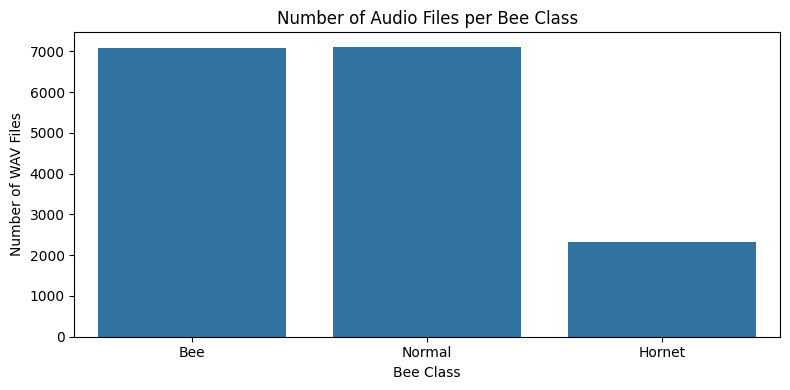

In [4]:
# audio 폴더와 클래스별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

files_counts = count_audio_files(AUDIO_DIR, CLASSES, extension='*.wav')

# 각 클래스
validate_minimum_files_per_class(files_counts, minimum_count=3)

file_counts_df = pd.DataFrame(list(files_counts.items()), columns=['Class', 'Count'])

print_section_title('데이터 폴더 및 파일 개수 확인')
print('원본 오디오 루트 경로:', AUDIO_DIR)
print('스팩트로그램 저장 경로:', SPEC_DIR)
print('분할 데이터 저장 경로:', SPLIT_DIR)
print(file_counts_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=file_counts_df, x='Class', y='Count')
plt.title('Number of Audio Files per Bee Class')
plt.xlabel('Bee Class')
plt.ylabel('Number of WAV Files')
plt.tight_layout()
plt.show()

# 오디오 데이터 증강

In [5]:
# 증강데이터 삭제용
# hornet_dir = os.path.join(AUDIO_DIR, 'Hornet_')

# for file in os.listdir(hornet_dir):
#     if file.endswith('_aug_0.wav'):
#         file_path = os.path.join(hornet_dir, file)
#         os.remove(file_path)
#         print(f"삭제됨: {file}")

In [6]:
# from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

# augment = Compose([
#     AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
#     TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
#     PitchShift(min_semitones=-2, max_semitones=2, p=0.5),
#     Shift(min_shift=-0.5, max_shift=0.5, p=0.5),
# ])

In [7]:
# import soundfile as sf

# hornet_dir = os.path.join(AUDIO_DIR, 'Hornet')

# for file in os.listdir(hornet_dir):
#     file_path = os.path.join(hornet_dir, file)

#     # 1. 오디오 로드
#     y, sr = librosa.load(file_path, sr=SR)
#     aug_dir = os.path.join(AUDIO_DIR, 'Hornet_aug')
#     os.makedirs(aug_dir, exist_ok=True)

#     # 2. 증강
#     for i in range(3):  # 3배 증강
#         augmented = augment(samples=y, sample_rate=sr)

#         new_file_path = os.path.join(
#             hornet_dir,
#             file.replace(".wav", f"_aug_{i}.wav")
#         )

#         sf.write(new_file_path, augmented, sr)

# 오디오 로드 함수 정의

In [8]:
def load_audio_file(file_path, sr=SR, duration=DURATION):
    """
    오디오 파일을 모노 신호로 읽고, 지정 길이로 고정한다.

    설계 의도:
    - 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
    - 너무 짧은 파일은 zero-padding한다.
    - 너무 긴 파일은 앞부분을 사용한다.
    - 실습/강의 환경에서 mp3 코덱 또는 파일 경로 문제를 조기에 감지할 수 있도록 예외를 명확히 전달한다.
    """

    # 입력 경로가 문자열인지 확인한다.
    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입: {type(file_path)}")

    # 실제 파일 존재 여부를 먼저 확인한다.
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다: {file_path}")

    # 파일 확장자를 확인한다. 이 실습은 mp3를 기본으로 가정하지만 wav 등으로 확장 가능하다.
    valid_exts = [".mp3", ".wav", ".flac", ".ogg", ".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다: {ext}")

    try:
        # mono=True는 스테레오 입력을 단일 채널로 평균/변환하여 처리 일관성을 확보한다.
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패: {file_path}\n원인: {e}")

    # 비어 있는 배열이 들어오면 이후 FFT/STFT에서 실패하므로 사전 차단한다.
    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디오 데이터가 비어 있습니다: {file_path}")

    # 목표 샘플 길이를 계산한다.
    target_length = int(sr * duration)

    # 길이가 짧으면 뒤를 0으로 패딩하여 고정 길이를 맞춘다.
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')

    # 길이가 길면 앞부분만 사용한다.
    else:
        y = y[:target_length]

    return y, sr

In [9]:
sample_file = None
sample_class = None

for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, '*.wav')
    files = glob.glob(pattern)
    if len(files) > 0:
        sample_file = files[0]
        sample_class = cls
        break

if sample_file is None:
    raise FileNotFoundError('[오류] 샘플로 사용할 mp3 파일을 찾지 못했습니다.')

y_sample, sr_sample = load_audio_file(sample_file)

print_section_title('샘플 오디오 정보')
print('샘플 클래스:', sample_class)
print('샘플 파일:', sample_file)
print('샘플링 주파수:', sr_sample)
print('총 샘플 수:', len(y_sample))
print('총 길이(초):', len(y_sample) / sr_sample)


샘플 오디오 정보
샘플 클래스: Bee
샘플 파일: c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\audio\Bee\output_Bee_0_Bee_0_0000.wav
샘플링 주파수: 32768
총 샘플 수: 49152
총 길이(초): 1.5


# waveform 시각화

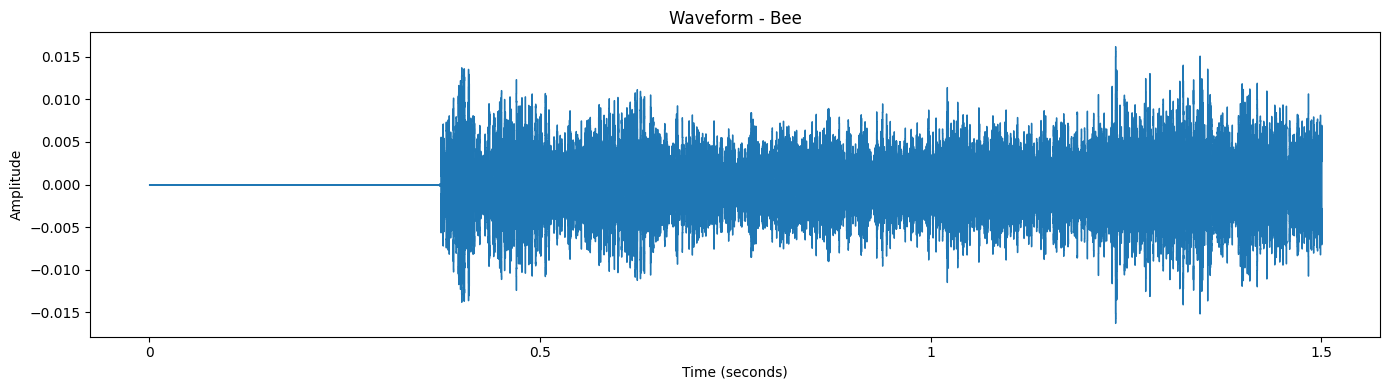

In [10]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y_sample, sr=sr_sample)
plt.title(f'Waveform - {sample_class}')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# FFT 시각화

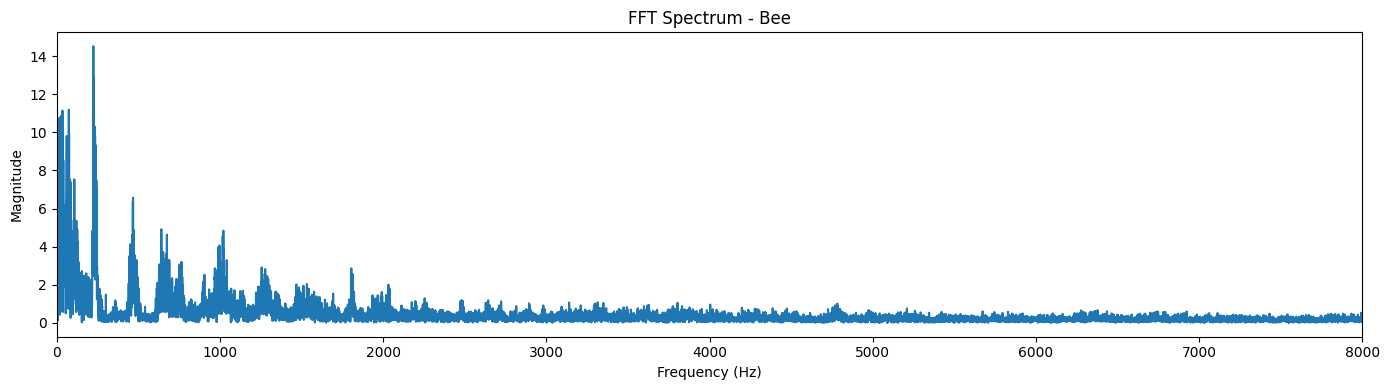

In [11]:
fft_sample = np.fft.fft(y_sample)

magnitude_sample = np.abs(fft_sample)

freq_sample = np.fft.fftfreq(len(magnitude_sample), d=1 / sr_sample)

positive_freq_sample = freq_sample[:len(freq_sample) // 2]
positive_magnitude_sample = magnitude_sample[:len(magnitude_sample) // 2]

plt.figure(figsize=(14, 4))
plt.plot(positive_freq_sample, positive_magnitude_sample)
plt.title(f'FFT Spectrum - {sample_class}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 8000)
plt.tight_layout()
plt.show()

# Spectogram 시각화

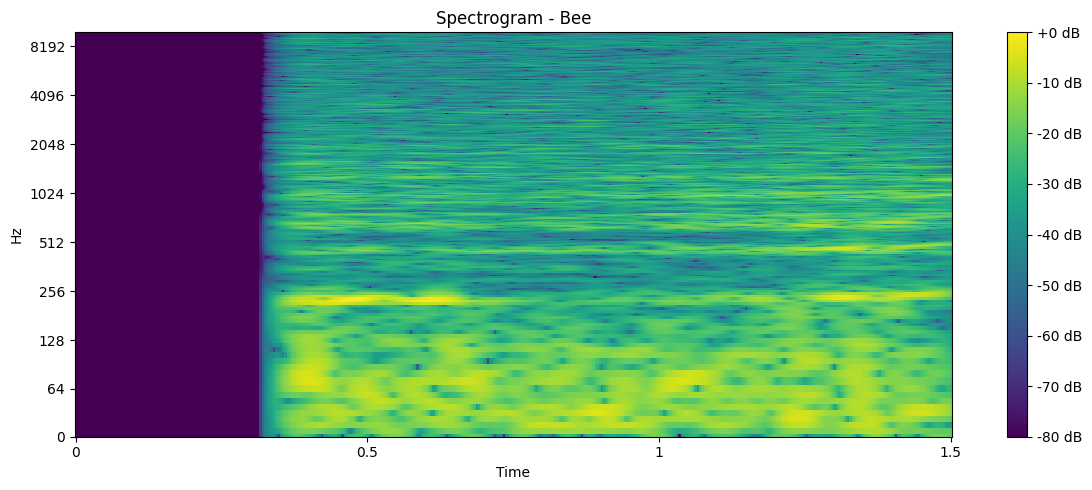

In [12]:
stft_sample = librosa.stft(y_sample, n_fft=N_FFT, hop_length=HOP_LENGTH)

spectrogram_sample = np.abs(stft_sample)

spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    spectrogram_db_sample,
    sr=sr_sample,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='log',
    cmap='viridis'
)

plt.colorbar(format='%+2.0f dB')
plt.title(f'Spectrogram - {sample_class}')
plt.tight_layout()
plt.ylim(0, 10000)
plt.show()

# 이미지 저장 함수 & Feature Engineering

In [ ]:
from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt, find_peaks

def highpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='high', analog=False)

    if len(data) <= max(len(a), len(b)) * 3:
        return data

    filtered_data = filtfilt(b, a, data)
    return filtered_data

def save_spectogram_image_enhanced(
    audio_path,
    save_path,
    sr=SR,
    duration=DURATION,
    apply_highpass=True,
    cutoff_freq=150,
    emphasize_ranges=None,
    band_weights=None,
    peak_boost=True,
    peak_boost_strength=1.25,
    peak_prominence_ratio=0.05,
    non_target_attenuation=0.85,
):
    """
    스펙토그램 저장 시:
    1) High-pass filter 적용 가능
    2) 특정 주파수 대역 강조
    3) band별 intensity 조정
    4) peak 위치 강조
    """
    
    save_dir = os.path.dirname(save_path)
    if save_dir != '':
        ensure_directory_exists(save_dir)

    # 오디오 로드
    y, sr = load_audio_file(audio_path, sr=sr, duration=duration)

    # 1) High-pass Filter 적용
    if apply_highpass:
        try:
            y = highpass_filter(y, cutoff=cutoff_freq, fs=sr, order=5)
        except Exception as e:
            print(f"[경고] highpass filter 실패: {audio_path} -> {e}")

    # 2) 멜 스펙트로그램 계산
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    mel_freqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=sr / 2)

    enhanced_spec = mel_spec.copy()

    # --------------------------------------------------
    # 1) 특정 주파수 범위 강조
    # emphasize_ranges: [(fmin, fmax, gain), ...]
    # 예: [(90, 300, 1.3), (300, 1200, 1.15)]
    # --------------------------------------------------
    if emphasize_ranges is not None:
        enhanced_spec *= non_target_attenuation

        for fmin, fmax, gain in emphasize_ranges:
            idx = np.where((mel_freqs >= fmin) & (mel_freqs < fmax))[0]
            if len(idx) > 0:
                enhanced_spec[idx, :] = mel_spec[idx, :] * gain

    # --------------------------------------------------
    # 2) band별 intensity 조정
    # band_weights: [(fmin, fmax, weight), ...]
    # 예: [(90,150,1.4), (150,300,1.3), (300,600,1.2), (600,1200,1.1), (1200,4000,0.9)]
    # --------------------------------------------------
    if band_weights is not None:
        for fmin, fmax, weight in band_weights:
            idx = np.where((mel_freqs >= fmin) & (mel_freqs < fmax))[0]
            if len(idx) > 0:
                enhanced_spec[idx, :] *= weight

    # --------------------------------------------------
    # 3) peak 위치 강조
    # 주파수별 평균 에너지 프로파일에서 peak를 찾아 해당 bin 주변을 부스트
    # --------------------------------------------------
    if peak_boost:
        freq_profile = np.mean(enhanced_spec, axis=1)

        if np.max(freq_profile) > 0:
            peaks, _ = find_peaks(
                freq_profile,
                prominence=np.max(freq_profile) * peak_prominence_ratio
            )

            for p in peaks:
                # peak bin과 주변 bin까지 강조
                left = max(0, p - 1)
                right = min(len(freq_profile), p + 2)
                enhanced_spec[left:right, :] *= peak_boost_strength

    # 값 안정화
    enhanced_spec = np.maximum(enhanced_spec, 1e-10)

    # dB 단위로 변환한다.
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    fig = plt.figure(figsize=(4, 4))
    
    librosa.display.specshow(mel_spec_db, sr=sr, hop_length=HOP_LENGTH, x_axis=None, y_axis=None, cmap='viridis')
    
    plt.axis('off')
    
    plt.tight_layout(pad=0)
    
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    
    plt.close(fig)
    
    img = Image.open(save_path).convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img.save(save_path)

# 전체 오디오 파일 -> 피처 엔지니어링된 Spectogram 이미지 생성

In [ ]:
safe_remove_path(SPEC_DIR)

ensure_directory_exists(SPEC_DIR)

print_section_title('오디오 파일을 스펙트로그램 이미지로 변환 중...')

# 각 클래스별로 오디오 파일을 읽어서 스펙트로그램 이미지로 저장
for cls in CLASSES:
    class_audio_dir = os.path.join(AUDIO_DIR, cls)
    class_spec_dir = os.path.join(SPEC_DIR, cls)

    # 클래스 별 스펙트로그램 저장 폴더 생성
    ensure_directory_exists(class_spec_dir)

    # 해당 클래스의 모든 mp3 파일을 가져오기
    audio_files = glob.glob(os.path.join(class_audio_dir, '*.wav'))
    
    # 랜덤 셔플 후 1000개만 선택
    random.shuffle(audio_files)
    selected_files = audio_files[:500]

    # 처리 현황을 출력
    print(f'{cls}: {len(selected_files)}개 파일 처리 중...')

    # 각 파일을 spectrogram 으로 변환
    for audio_file in selected_files:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(class_spec_dir, f'{base_name}.png')
    
        if cls == "Bee":
            cutoff = 150
            save_spectogram_image_enhanced(
                audio_file,
                save_path,
                emphasize_ranges=[(150, 1200, 1.25)],
                band_weights=[
                    (150, 300, 1.35),
                    (300, 600, 1.25),
                    (600, 1200, 1.15),
                    (1200, 4000, 0.90),
                ],
                peak_boost=True,
                peak_boost_strength=1.15
            )
    
        elif cls == "Hornet":
            cutoff = 90
            save_spectogram_image_enhanced(
                audio_file,
                save_path,
                emphasize_ranges=[(90, 2000, 1.20)],
                band_weights=[
                    (90, 150, 1.20),
                    (150, 300, 1.20),
                    (300, 600, 1.20),
                    (600, 1200, 1.25),
                    (1200, 2000, 1.10),
                ],
                peak_boost=True,
                peak_boost_strength=1.25
            )
    
        else:
            cutoff = None
            
            save_spectogram_image_enhanced(
                audio_file,
                save_path,
                apply_highpass=False,
                cutoff_freq=150,
                emphasize_ranges=None,
                band_weights=None,
                peak_boost=False
            )

print('스펙토그램 이미지 생성 완료')


오디오 파일을 스펙트로그램 이미지로 변환 중...
Bee: 500개 파일 처리 중...
Normal: 500개 파일 처리 중...
Hornet: 500개 파일 처리 중...
스펙토그램 이미지 생성 완료


# train / val / test 분할 함수

In [18]:
def split_dataset_to_folders(source_dir, target_dir, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    spectrogram 이미지를 클래스별 train/val/test 폴더 구조로 분할
    """

    # 기존 split 폴더를 삭제
    safe_remove_path(target_dir)

    # 비율의 합이 1인지 검증
    if abs(train_ratio + val_ratio + test_ratio - 1.0) >= 1e-6:
        raise ValueError("[오류] train_ratio + val_ratio + test_ratio의 합은 반드시 1이어야 함")

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        # 원본 클래스 이미지가 존재하는지 확인
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] spectrogram 클래스 폴더가 없습니다: {class_dir}")

        image_files = glob.glob(os.path.join(class_dir, "*.png"))

        # 클래스별 이미지가 없으면 학습 불가이므로 중단
        if len(image_files) == 0:
            raise ValueError(f"[오류] 클래스 '{cls}'의 spectrogram 이미지가 없습니다.")

        # 무작위 셔플 후 분할
        random.shuffle(image_files)

        n_total = len(image_files)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_files = image_files[:n_train]
        val_files = image_files[n_train:n_train + n_val]
        test_files = image_files[n_train + n_val:]

        # split별 폴더를 생성
        for split_name in ["train", "val", "test"]:
            ensure_directory_exists(os.path.join(target_dir, split_name, cls))

        # 복사 보조 함수
        def copy_files(files, split_name):
            for f in files:
                dst = os.path.join(target_dir, split_name, cls, os.path.basename(f))
                shutil.copy2(f, dst)

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

        print(f"{cls} -> train:{len(train_files)}, val:{len(val_files)}, test:{len(test_files)}")


def validate_split_dataset(target_dir, classes):
    """
    split 이후 각 train/val/test/class 폴더에 최소 1개 이상의 이미지가 있는지 검증한다.
    """
    print_section_title("분할 데이터셋 검증")
    for split_name in ["train", "val", "test"]:
        print(f"[{split_name}]")
        for cls in classes:
            class_dir = os.path.join(target_dir, split_name, cls)
            count = len(glob.glob(os.path.join(class_dir, "*.png")))
            print(f"  {cls}: {count}개")
            if count == 0:
                raise ValueError(
                    f"[오류] {split_name}/{cls} 폴더에 이미지가 없습니다. "
                    f"클래스별 샘플 수가 너무 적거나 분할 비율 조정이 필요합니다."
                )

# 데이터셋 분할 수행

In [19]:
print_section_title('train / val / test 데이터셋 분할 중...')
split_dataset_to_folders(SPEC_DIR, SPLIT_DIR, CLASSES, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
validate_split_dataset(SPLIT_DIR, CLASSES)
print('데이터셋 분할 완료')


train / val / test 데이터셋 분할 중...
Bee -> train:350, val:75, test:75
Normal -> train:350, val:75, test:75
Hornet -> train:350, val:75, test:75

분할 데이터셋 검증
[train]
  Bee: 350개
  Normal: 350개
  Hornet: 350개
[val]
  Bee: 75개
  Normal: 75개
  Hornet: 75개
[test]
  Bee: 75개
  Normal: 75개
  Hornet: 75개
데이터셋 분할 완료


# ImageDataGenerator로 데이터 로드 및 증강 설정

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
)

val_test_datagen = ImageDataGenerator(rescale=1/255)

train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'val'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'test'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

# 클래스 인덱스 매핑 출력
print_section_title('클래스 인덱스 매핑')
print(train_generator.class_indices)

# index -> class 이름 역매핑을 미리 만들어줌
idx_to_class = {v : k for k, v in train_generator.class_indices.items()}
print('역매핑:', idx_to_class)

Found 1050 images belonging to 3 classes.
Found 225 images belonging to 3 classes.
Found 225 images belonging to 3 classes.

클래스 인덱스 매핑
{'Bee': 0, 'Hornet': 1, 'Normal': 2}
역매핑: {0: 'Bee', 1: 'Hornet', 2: 'Normal'}


# CNN 모델 정의

In [21]:
# 입력 shape는 고정된 spectrogram RGB 이미지 크기
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Sequential 모델 생성
model = models.Sequential()

# Block 1:
# 저수준 edge/texture 패턴을 추출
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2:
# 더 복잡한 주파수 리지, 하모닉 구조, 시간-주파수 패턴을 학습
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3:
# 중간 수준의 패턴 조합을 표현
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 4:
# 클래스 구분력이 높은 상위 수준 특성을 형성
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# 2차원 feature map을 1차원 벡터로 변환
model.add(layers.Flatten())

# Dense layer는 학습된 로컬 패턴들을 종합하여 클래스 결정 경계를 형성
model.add(layers.Dense(256, activation='relu'))

# Dropout은 특정 뉴런 의존도를 줄여 과적합방지
model.add(layers.Dropout(0.5))

# 최종 출력층은 6개 클래스 확률 분포를 생성
model.add(layers.Dense(len(CLASSES), activation='softmax'))

# 다중 클래스 분류이므로 categorical_crossentropy를 사용
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조를 출력
print_section_title("CNN 모델 구조")
model.summary()


CNN 모델 구조


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,234,499 (50.49 MB)

 Trainable params: 13,234,499 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

# 학습 콜백 설정

In [22]:
# validation loss가 일정 epoch 동안 개선되지 않으면 학습 조기 종료
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

# validation accrucay가 최고일 때의 모델을 자동 저장
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 모델 학습

In [23]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.5299 - loss: 0.9766
Epoch 1: val_accuracy improved from -inf to 0.90222, saving model to c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\best_instrument_cnn_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 388ms/step - accuracy: 0.5318 - loss: 0.9733 - val_accuracy: 0.9022 - val_loss: 0.3067
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8603 - loss: 0.3708
Epoch 2: val_accuracy improved from 0.90222 to 0.96000, saving model to c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\best_instrument_cnn_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 396ms/step - accuracy: 0.8606 - loss: 0.3700 - val_accuracy: 0.9600 - val_loss: 0.1395
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9270 - loss: 0.2242
Epoch 3: val_accuracy improved from 0.96000 to 0.97333, saving model to c:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\best_instrument_cnn_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 415ms/step - accuracy: 0.927

# 학습 과정 시각화

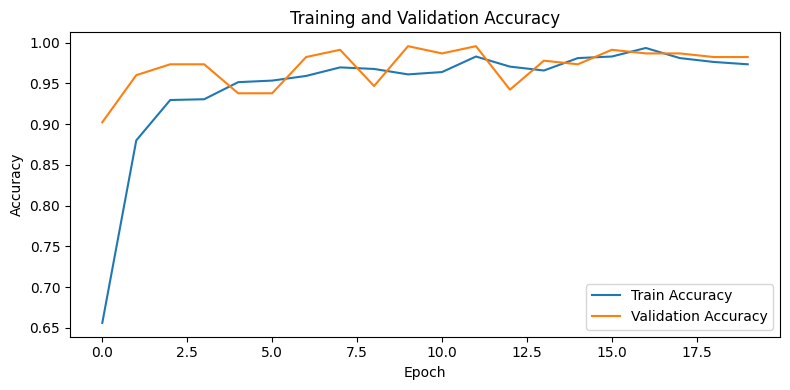

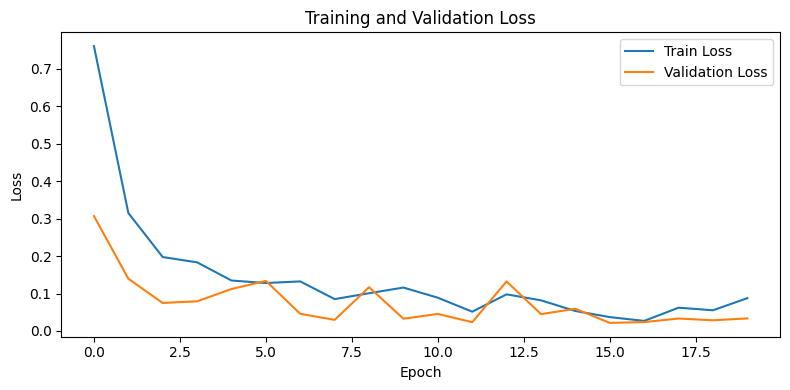

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# 테스트셋 분류 리포트 및 Confusion Matrix

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step

분류 리포트
              precision    recall  f1-score   support

         Bee       1.00      0.92      0.96        75
      Hornet       0.95      0.99      0.97        75
      Normal       0.95      0.99      0.97        75

    accuracy                           0.96       225
   macro avg       0.97      0.96      0.96       225
weighted avg       0.97      0.96      0.96       225



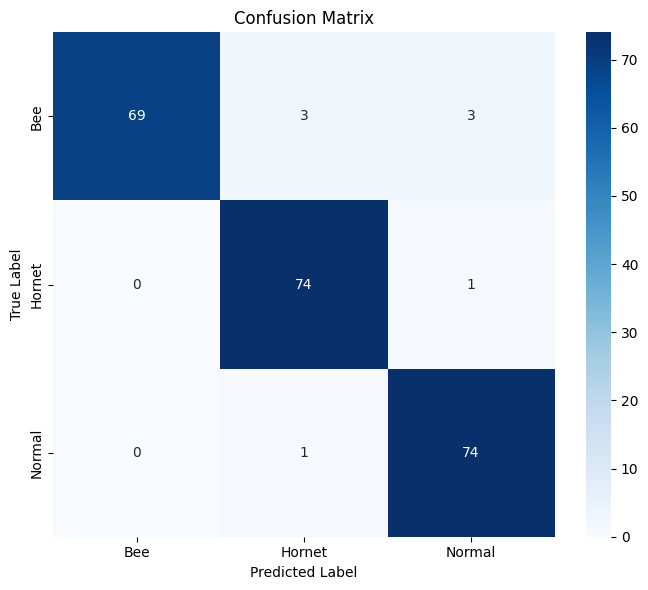

In [25]:
# 테스트셋 전체에 대해 클래스별 확률을 예측
pred_probs = model.predict(test_generator)

# 가장 큰 확률을 갖는 인덱스를 최종 예측 클래스로 사용
pred_classes = np.argmax(pred_probs, axis=1)

# 실제 정답 라벨
true_classes = test_generator.classes

# 클래스 이름 목록
class_labels = list(test_generator.class_indices.keys())

print_section_title("분류 리포트")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    zero_division=0
))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# 예측용 오디오 분석/시각화 함수

In [26]:
def visualize_audio_analysis(audio_path, predicted_class=None, probs_dict=None):
    """
    신규 입력 오디오에 대해 waveplot, FFT, spectrogram을 순차적으로 시각화
    """

    # 오디오를 로드
    y, sr = load_audio_file(audio_path)

    # 파일명만 표시용으로 추출
    file_name = os.path.basename(audio_path)

    # 1) waveplot 시각화
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Input Audio Waveform - {file_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    ()

    # 2) FFT 시각화
    fft_vals = np.fft.fft(y)
    magnitude = np.abs(fft_vals)
    freqs = np.fft.fftfreq(len(magnitude), d=1 / sr)
    positive_freqs = freqs[:len(freqs) // 2]
    positive_magnitude = magnitude[:len(magnitude) // 2]

    plt.figure(figsize=(14, 4))
    plt.plot(positive_freqs, positive_magnitude)
    plt.title(f"Input Audio FFT Spectrum - {file_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 8000)
    plt.tight_layout()
    ()

    # 3) Spectrogram 시각화
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(12, 5))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='log'
    )
    plt.colorbar(format='%+2.0f dB')
    if predicted_class is None:
        plt.title(f"Input Audio Spectrogram - {file_name}")
    else:
        plt.title(f"Input Audio Spectrogram - {file_name}\nPredicted: {predicted_class}")
    plt.tight_layout()
    ()

    # 4) 예측 확률 막대그래프
    if probs_dict is not None:
        probs_df = pd.DataFrame({
            "Class": list(probs_dict.keys()),
            "Probability": list(probs_dict.values())
        }).sort_values("Probability", ascending=False)

        plt.figure(figsize=(8, 4))
        sns.barplot(data=probs_df, x="Class", y="Probability")
        plt.title(f"Prediction Probability - {file_name}")
        plt.xlabel("Instrument Class")
        plt.ylabel("Probability")
        plt.xticks(rotation=30)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()

# 신규 오디오 예측 함수

In [27]:
def predict_instrument_from_audio_absolute_path(audio_path, model, class_indices, save_temp_image=False):
    """
    절대경로로 지정한 신규 오디오 파일을 읽어와 CNN으로 예측한다.

    기능:
    - 입력 파일 유효성 검사
    - spectrogram 임시 이미지 생성
    - 모델 추론
    - 예측 클래스 및 확률 반환
    - 입력 오디오 waveplot / FFT / spectrogram / 확률 시각화 수행
    """

    # 입력값 타입 검증
    if not isinstance(audio_path, str):
        raise TypeError("[오류] audio_path는 문자열이어야 합니다.")

    # 절대경로인지 확인한다. 사용자 요청 조건을 강제하기 위한 검증.
    if not os.path.isabs(audio_path):
        raise ValueError(f"[오류] 신규 오디오 예측 경로는 절대경로여야 합니다: {audio_path}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"[오류] 신규 예측용 오디오 파일이 존재하지 않습니다: {audio_path}")

    # 모델 유효성 확인
    if model is None:
        raise ValueError("[오류] 학습된 모델이 없습니다.")

    # 클래스 인덱스 매핑 확인
    if not isinstance(class_indices, dict) or len(class_indices) == 0:
        raise ValueError("[오류] class_indices가 비어 있거나 유효하지 않습니다.")

    # 임시 spectrogram 이미지가 남아 있으면 삭제
    if os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    # 신규 오디오를 spectrogram 이미지로 변환
    save_spectogram_image_enhanced(audio_path, TEMP_PREDICT_IMAGE_PATH)

    # 임시 이미지가 실제 생성되었는지 확인
    if not os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        raise FileNotFoundError("[오류] 예측용 임시 spectrogram 이미지 생성에 실패했습니다.")

    # 저장된 이미지를 열어 RGB 변환
    img = Image.open(TEMP_PREDICT_IMAGE_PATH).convert("RGB")

    # 모델 입력 크기로 리사이즈
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    # numpy 배열로 변환 후 0~1 범위로 정규화
    img_array = np.array(img).astype("float32") / 255.0

    # (H, W, C) -> (1, H, W, C)로 배치 축을 추가
    img_array = np.expand_dims(img_array, axis=0)

    # 모델 추론을 수행한다.
    probs = model.predict(img_array, verbose=0)[0]

    # 최대 확률 클래스 인덱스를 찾는다.
    pred_idx = int(np.argmax(probs))

    # index -> class 역매핑 생성
    idx_to_class_local = {v: k for k, v in class_indices.items()}

    # 예측 클래스 이름
    predicted_class = idx_to_class_local[pred_idx]

    # 클래스별 확률 dict 생성
    probs_dict = {idx_to_class_local[i]: float(probs[i]) for i in range(len(probs))}

    # 예측용 spectrogram 이미지 자체를 보여준다.
    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(TEMP_PREDICT_IMAGE_PATH))
    plt.title(f"Prediction Spectrogram\nPredicted: {predicted_class}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 입력 오디오의 wave/FFT/spectrogram/확률을 함께 시각화
    visualize_audio_analysis(
        audio_path=audio_path,
        predicted_class=predicted_class,
        probs_dict=probs_dict
    )

    # 임시 저장을 원하지 않으면 삭제
    if not save_temp_image and os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    return predicted_class, probs_dict


신규 오디오 예측 준비
절대경로 입력 예시: C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\audio\Hornet\output_Hornet_1_Hornet_1_1718.wav


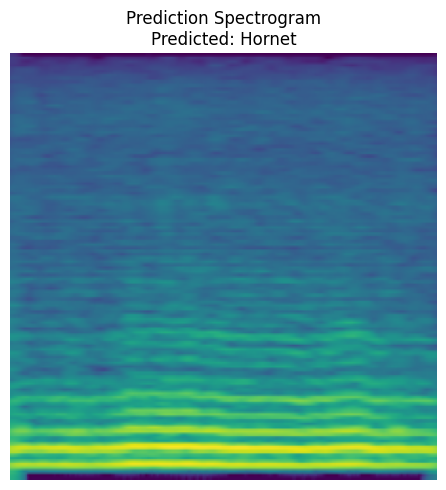

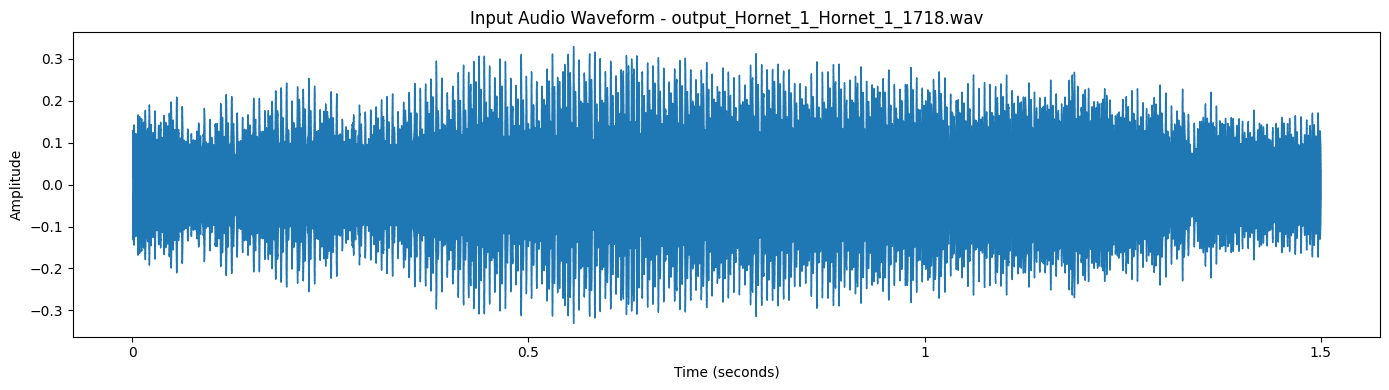

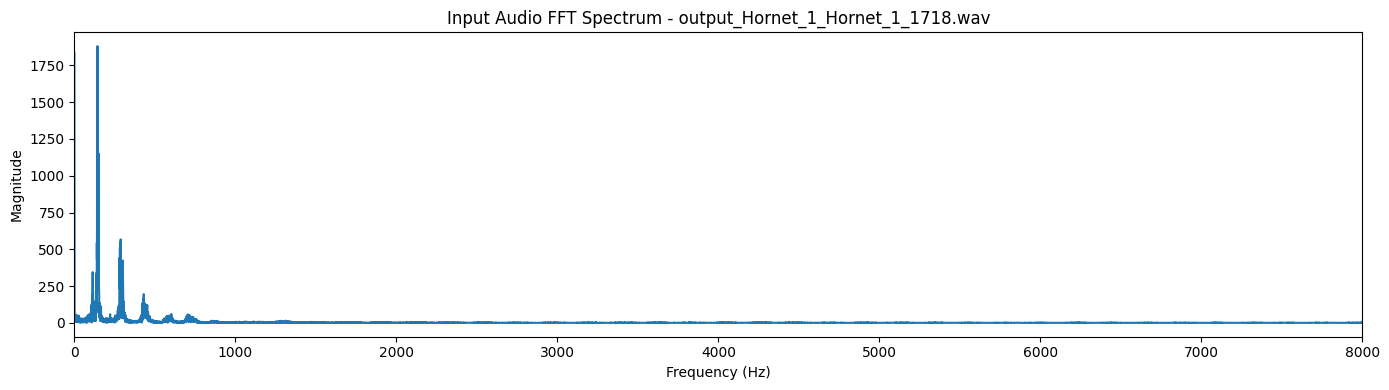

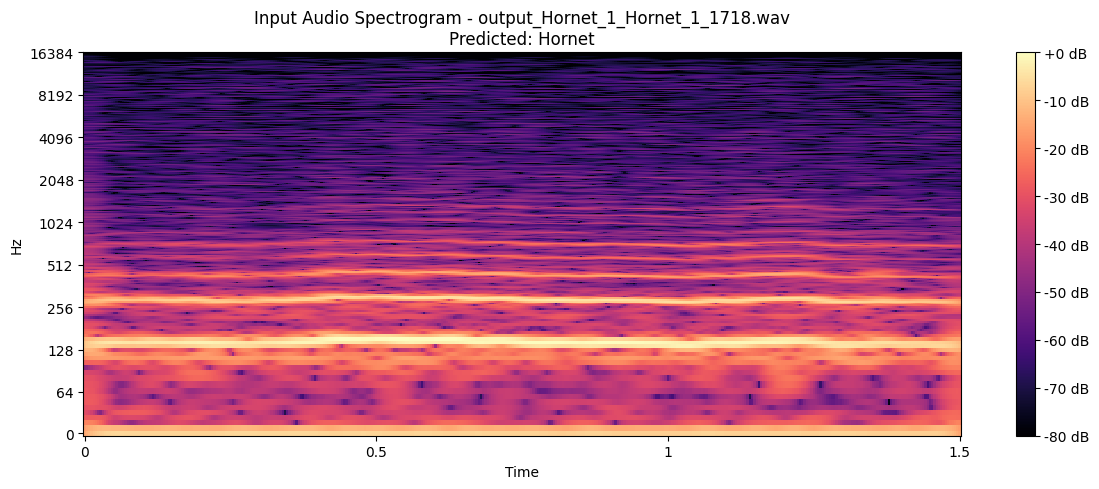

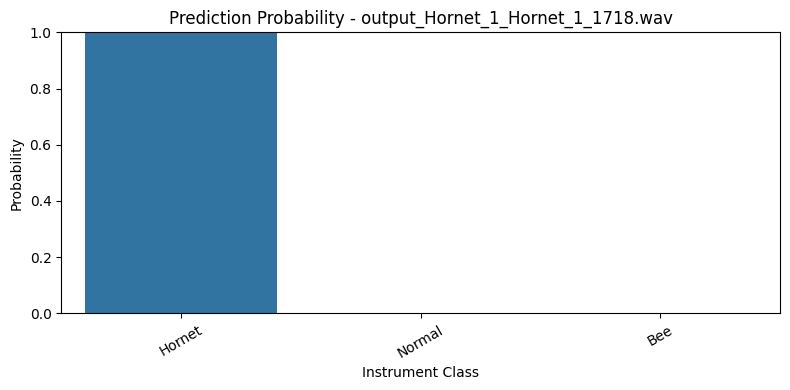

예측된 클래스: Hornet
클래스별 확률:
  Hornet: 1.0000
  Normal: 0.0000
  Bee: 0.0000


In [29]:
NEW_AUDIO_ABSOLUTE_PATH = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\audio\Hornet\output_Hornet_1_Hornet_1_1718.wav'

print_section_title("신규 오디오 예측 준비")
print('절대경로 입력 예시:', NEW_AUDIO_ABSOLUTE_PATH)

if os.path.isabs(NEW_AUDIO_ABSOLUTE_PATH):
    predicted_class, probs_dict = predict_instrument_from_audio_absolute_path(
        audio_path=NEW_AUDIO_ABSOLUTE_PATH,
        model=model,
        class_indices=train_generator.class_indices,
        save_temp_image=False
    )

    print(f"예측된 클래스: {predicted_class}")
    print("클래스별 확률:")
    for cls, prob in sorted(probs_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"  {cls}: {prob:.4f}")
else:
    print("[오류] NEW_AUDIO_ABSOLUTE_PATH 변수에 절대경로를 입력해주세요.")

# XAI 이미지 중요도 관측

In [30]:
import cv2
from tensorflow.keras.preprocessing import image

def build_gradcam_model_from_sequential(model, last_conv_layer_name, input_shape):
    # 새 입력 텐서를 만든 뒤, Sequential 레이어들을 순서대로 다시 연결
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    last_conv_output = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    if last_conv_output is None:
        raise ValueError(f"'{last_conv_layer_name}' 레이어를 찾지 못했음")

    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[last_conv_output, x]   # x가 최종 output
    )
    return grad_model

ModuleNotFoundError: No module named 'cv2'

In [ ]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, input_shape, pred_index=None):
    grad_model = build_gradcam_model_from_sequential(
        model=model,
        last_conv_layer_name=last_conv_layer_name,
        input_shape=input_shape
    )

    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    # 채널별 gradient 평균
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # feature map과 가중합
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # ReLU + normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index)

In [ ]:
def overlay_heatmap(img_path, heatmap, alpha=0.4, target_size=(224, 224)):
    # 🔥 안전하게 이미지 로드
    from PIL import Image

    if not os.path.exists(img_path):
        raise ValueError(f"이미지 경로 없음: {img_path}")

    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size)
    img = np.array(img)

    # heatmap resize
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # overlay
    result = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    return result

conv2d_8 Conv2D
max_pooling2d_8 MaxPooling2D
conv2d_9 Conv2D
max_pooling2d_9 MaxPooling2D
conv2d_10 Conv2D
max_pooling2d_10 MaxPooling2D
conv2d_11 Conv2D
max_pooling2d_11 MaxPooling2D
flatten_2 Flatten
dense_4 Dense
dropout_2 Dropout
dense_5 Dense


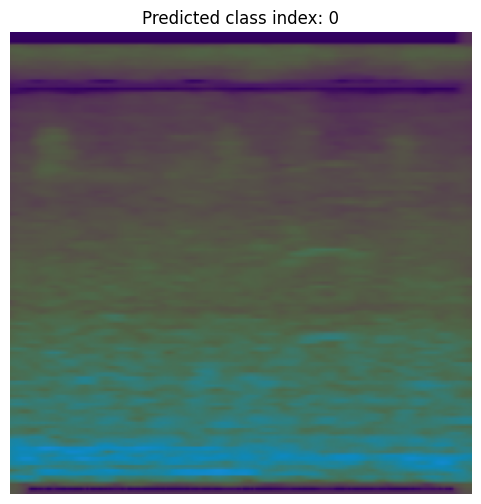

In [ ]:
img_path = r"C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\spectrogram_data\Hornet\output_Hornet_1_Hornet_1_1356.png"

img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img).astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

heatmap, pred_class = get_gradcam_heatmap(
    model=model,
    img_array=img_array,
    last_conv_layer_name='conv2d_3',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

result = overlay_heatmap(
    img_path=img_path,
    heatmap=heatmap,
    alpha=0.4,
    target_size=(IMG_WIDTH, IMG_HEIGHT)
)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted class index: {pred_class}")
plt.axis("off")
plt.show()

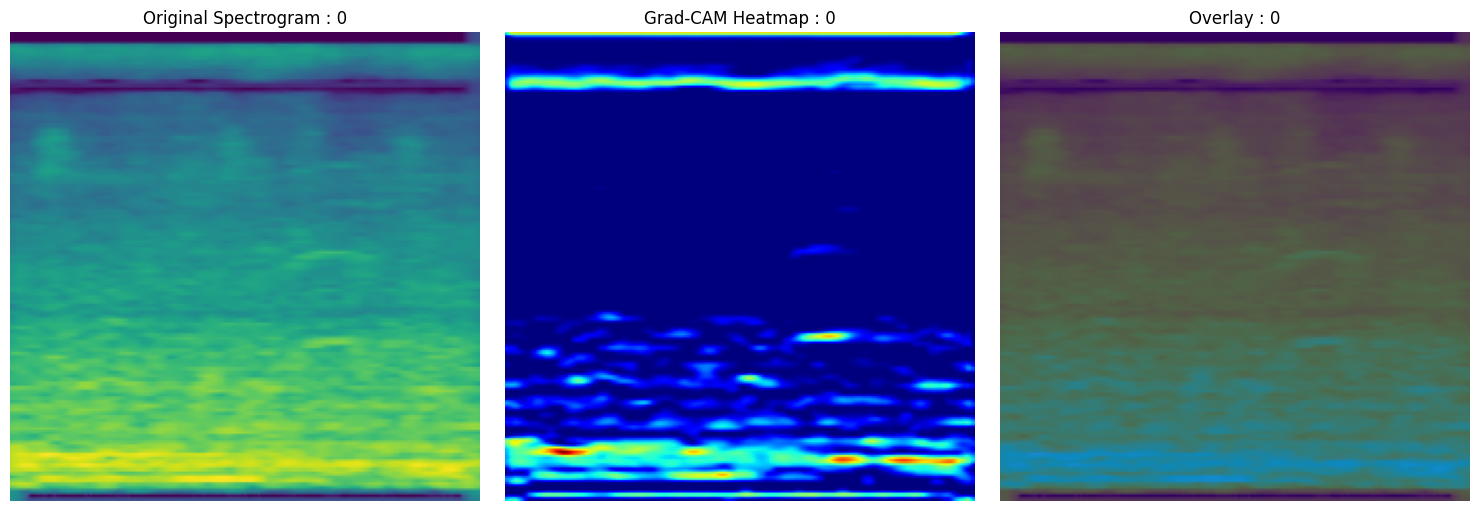

In [ ]:
def show_gradcam_triplet(img_path, heatmap, overlay_img, target_size=(224, 224)):
    if not os.path.exists(img_path):
        raise ValueError(f"이미지 경로 없음: {img_path}")

    # 🔥 PIL로 안전하게 로드
    original = Image.open(img_path).convert("RGB")
    original = original.resize(target_size)
    original = np.array(original)

    # heatmap resize
    heatmap_resized = cv2.resize(heatmap, target_size)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title(f"Original Spectrogram : {pred_class}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title(f"Grad-CAM Heatmap : {pred_class}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Overlay : {pred_class}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
    
show_gradcam_triplet(
    img_path=img_path,
    heatmap=heatmap,
    overlay_img=result,
    target_size=(IMG_WIDTH, IMG_HEIGHT)
)

In [ ]:
def save_gradcam_triplet(img_path, heatmap, overlay_img, save_path, target_size=(224, 224), pred_text=None):
    original = Image.open(img_path).convert("RGB")
    original = original.resize(target_size)
    original = np.array(original)

    heatmap_resized = cv2.resize(heatmap, target_size)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original Spectrogram")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    plt.title(pred_text if pred_text else "Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1)
    plt.close()

In [ ]:
def load_image_for_model(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [ ]:
def save_gradcam_image(model, img_path, save_path, last_conv_layer_name, img_height, img_width, idx_to_class=None):
    img_array = load_image_for_model(img_path, target_size=(img_height, img_width))

    heatmap, pred_class = get_gradcam_heatmap(
        model=model,
        img_array=img_array,
        last_conv_layer_name=last_conv_layer_name,
        input_shape=(img_height, img_width, 3)
    )

    overlay_img = overlay_heatmap(
        img_path=img_path,
        heatmap=heatmap,
        alpha=0.4,
        target_size=(img_width, img_height)
    )

    true_label = os.path.basename(os.path.dirname(img_path))

    if idx_to_class is not None:
        pred_label = idx_to_class[pred_class]
    else:
        pred_label = str(pred_class)

    save_gradcam_triplet(
        img_path=img_path,
        heatmap=heatmap,
        overlay_img=overlay_img,
        save_path=save_path,
        target_size=(img_width, img_height),
        pred_text=f"True: {true_label} | Pred: {pred_label}"
    )

In [ ]:
GRADCAM_DIR = './gradcam_results'

# safe_remove_path(GRADCAM_DIR)
ensure_directory_exists(GRADCAM_DIR)

print_section_title('Grad-CAM 이미지 생성 중...')

# 각 클래스별로 스펙트로그램 이미지를 읽어서 Grad-CAM 결과 저장
for cls in CLASSES:
    class_spec_dir = os.path.join(SPEC_DIR, cls)
    class_gradcam_dir = os.path.join(GRADCAM_DIR, cls)

    # 클래스별 Grad-CAM 저장 폴더 생성
    ensure_directory_exists(class_gradcam_dir)

    # 해당 클래스의 모든 spectrogram png 파일 가져오기
    spec_files = glob.glob(os.path.join(class_spec_dir, '*.png'))

    print(f'{cls}: {len(spec_files)}개 이미지 처리 중...')

    # 각 spectrogram 이미지에 대해 Grad-CAM 결과 생성
    for spec_file in spec_files:
        base_name = os.path.splitext(os.path.basename(spec_file))[0]
        save_path = os.path.join(class_gradcam_dir, f'{base_name}_gradcam.png')

        try:
            save_gradcam_image(
                model=model,
                img_path=spec_file,
                save_path=save_path,
                last_conv_layer_name='conv2d_3',   # 필요시 수정
                img_height=IMG_HEIGHT,
                img_width=IMG_WIDTH,
                idx_to_class=sorted(CLASSES)
            )
        except Exception as e:
            print(f'에러 발생: {spec_file} -> {e}')

print('Grad-CAM 이미지 생성 완료')


Grad-CAM 이미지 생성 중...
Bee: 500개 이미지 처리 중...
Normal: 500개 이미지 처리 중...
Hornet: 500개 이미지 처리 중...
Grad-CAM 이미지 생성 완료
